# Search for Co-transmitting Neurons

In [2]:
# Add auto reload
%load_ext autoreload
%autoreload 2

## Initial set up 
I will use both the codex and fafbseg libraries to obtain data. These tokens should be in the `.env` file. The actual tokens are stored in the OnePassword vault.

In [3]:
#libraries
import os
import numpy as np
import pandas as pd
from decouple import config, Config, RepositoryEnv
from caveclient import CAVEclient
from fafbseg import flywire
from getpass import getpass
import seaborn as sns
import matplotlib.pyplot as plt
import navis
import datetime

# Get variables from the .env file
ENV_PATH = "../.env"
config = Config(RepositoryEnv(ENV_PATH))

### CAV Client ###
# Get the CAVE_AUTH_TOKEN
cave_token = config("CAVE_AUTH_TOKEN", default=None)
if not cave_token:
    print("No CAVE token found in the .env file.")
    temp_token = getpass("Token not found in the .env file. Please enter your CAVE token (if you don't have one leave if blank and instructions will appear): ")
    if temp_token:
        cave_token = temp_token
    else:
        print("No CAVE token entered. Follow the information below to get a token.")
        CAVEclient.auth.get_new_token()
if cave_token:
    # Initialize the CAVE client
    client = CAVEclient('flywire_fafb_public')
    auth = client.auth
    tk = auth.token
    if not tk:
        print("Adding the token to your account. You only need to do this once.")
        auth.save_token(cave_token)
    else:
        print("CAVE token already exists in your account. No need to add it again.")

### Get the FLYWIRE_AUTH_TOKEN ###
flywire_token = config("FLYWIRE_AUTH_TOKEN", default=None)
tk = flywire.get_chunkedgraph_secret()
if not tk:
    print("No FLYWIRE token saved. Setting it with the value from the .env file.")
    if not flywire_token:
        flywire_token = getpass("Token not found in the .env file. Please enter your FLYWIRE token (if you don't have one leave if blank and instructions will appear): ")
        if not flywire_token:
            print("No FLYWIRE token entered. Follow the information below to get a token.")
            flywire.get_new_token()
        else:
            print("Setting the FLYWIRE token with the value from the .env file.")
            #Save the secret
            flywire.set_chunkedgraph_secret(flywire_token)
else:
    print("FLYWIRE token already exists in your account. No need to add it again.")

/opt/anaconda3/envs/fau_connectomics/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CAVE token already exists in your account. No need to add it again.
FLYWIRE token already exists in your account. No need to add it again.


## Test that the CAVE client works

In [4]:
# root_id= "720575940624928574"
root_id = "720575940607155890" #Mushroom body neuron
pre_df = client.materialize.query_table(
    table='synapses_nt_v1',
    filter_in_dict={'pre_pt_root_id': [root_id]},
)

In [5]:
pre_df

,id,created,superceded_id,valid,connection_score,cleft_score,gaba,ach,glut,oct,ser,da,valid_nt,pre_pt_supervoxel_id,pre_pt_root_id,post_pt_supervoxel_id,post_pt_root_id,pre_pt_position,post_pt_position
0,508985,2021-03-09 20:14:58.183080+00:00,NaN,t,86.188599,142,0.017340,0.064045,0.038678,0.000318,0.033393,0.846226,t,80293211209681776,720575940607155890,80293211209687414,720575940607155890,"[563932, 171384, 74560]","[564024, 171448, 74560]"
1,15429442,2021-03-09 20:14:58.183080+00:00,NaN,t,164.778198,112,0.005293,0.310279,0.006239,0.003252,0.662614,0.012324,t,80293554739826794,720575940607155890,80293554739826764,720575940397140598,"[563400, 193200, 50560]","[563528, 193208, 50520]"
2,27594708,2021-03-09 20:14:58.183080+00:00,NaN,t,94.334541,7,0.204758,0.160491,0.156203,0.006174,0.074122,0.398252,t,80081830099025888,720575940607155890,80081830099029582,720575940387491554,"[551012, 157524, 67720]","[550936, 157340, 67680]"
3,1059342,2021-03-09 20:14:58.183080+00:00,NaN,t,17.228376,30,0.028138,0.666006,0.005373,0.002674,0.007495,0.290314,t,80927904296794384,720575940607155890,80927904296791557,720575940659019649,"[600952, 254196, 74040]","[601008, 254136, 74040]"
4,524492,2021-03-09 20:14:58.183080+00:00,NaN,t,26.879395,144,0.049338,0.796867,0.026185,0.007607,0.007234,0.112770,t,80294173282369181,720575940607155890,80294173282351514,720575940608123791,"[564620, 230624, 74480]","[564656, 230608, 74400]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23556,177902921,2021-03-09 20:14:58.183080+00:00,NaN,t,58.880764,15,0.004604,0.977955,0.001287,0.009586,0.000029,0.006539,t,80786342107755149,720575940607155890,80786342107774430,720575940627680911,"[591992, 205424, 58240]","[591952, 205304, 58160]"
23557,152938359,2021-03-09 20:14:58.183080+00:00,NaN,t,97.423248,88,0.015980,0.910355,0.007352,0.031925,0.000154,0.034235,t,80224079483223866,720575940607155890,80224079483229590,720575940613891442,"[559472, 244360, 95240]","[559480, 244272, 95280]"
23558,183059521,2021-03-09 20:14:58.183080+00:00,NaN,t,56.110470,153,0.014186,0.908789,0.000133,0.000121,0.002113,0.074659,t,80927766857704453,720575940607155890,80927766857701889,720575940629981440,"[599072, 246448, 70600]","[599056, 246360, 70560]"
23559,153048500,2021-03-09 20:14:58.183080+00:00,NaN,t,469.687744,145,0.116572,0.792189,0.018135,0.000561,0.015121,0.057422,t,79238504747841371,720575940607155890,79238504747838225,720575940629981440,"[503060, 220832, 94360]","[503112, 220764, 94320]"


## Build a function to identify highly contributing neurons
Idea: Test ratios of synapses in order to confirm contributions

In [6]:
# Function 1: Get the dataframes
def get_codex_synapse_predictions(root_id, client):
    """
    Function to gather synapse predictions for a given root ID.
    """

    # Pull initial data from the CAVE client
    pre_df = client.materialize.query_table(
        table='synapses_nt_v1',
        filter_in_dict={'pre_pt_root_id': [root_id]},
    )

    return pre_df

# Function 2: Get the neuron skeleton
def get_neuron_skeleton(root_id):
    """
    Function to gather the neuron skeleton for a given root ID.
    """
    neuron_skeleton = flywire.get_skeletons(root_id)

    return neuron_skeleton

# Function 3: Identify NT contributions per neuron
def identify_nt_contributions(pre_df, softmax_threshold=0.25):
    """
    Function to identify neurotransmitter contributions per neuron.
    Inputs:
    pre_df: DataFrame containing synapse predictions with columns for each neurotransmitter type.
    softmax_threshold: Float, the threshold below which a neurotransmitter is considered 'Unknown'.

    Returns:
    nt_counts: a dictionary with counts of each neurotransmitter type.
    synapse_predictions: a numpy array with synapse predictions for each neurotransmitter type. (NB excludes 'Unknown' type)
    """

    #Synapse predictions
    synapse_predictions = np.zeros((len(pre_df), 6), dtype=np.float32)
    for i in range(pre_df.shape[0]):
        row = [pre_df.iloc[i]['gaba'], pre_df.iloc[i]['ach'], pre_df.iloc[i]['glut'], pre_df.iloc[i]['oct'], pre_df.iloc[i]['ser'], pre_df.iloc[i]['da']]
        synapse_predictions[i] = row
        
    # Define neurotransmitter types
    nt_types = ['GABA', 'ACh', 'Glut', 'Oct', 'Ser', 'DA', 'Unknown']
    
    # Initialize counts and filter along softmax values
    nt_counts = {nt: 0 for nt in nt_types}
    softmax_prediction_vals = {nt: [] for nt in nt_types}

    for i in range(pre_df.shape[0]):
        # Determine the synapse type based on the maximum prediction value  
        synapse_type = np.argmax(pre_df.iloc[i][['gaba', 'ach', 'glut', 'oct', 'ser', 'da']].values)
        softmax_val = np.max(pre_df.iloc[i][['gaba', 'ach', 'glut', 'oct', 'ser', 'da']].values)
        if softmax_val < softmax_threshold:
            synapse_type = 6  # Assign 'Unknown' if below threshold
        
        # Add the softmax value to the corresponding neurotransmitter type
        softmax_prediction_vals[nt_types[synapse_type]].append(softmax_val)
        
        # Increment the count for the neurotransmitter type
        nt_counts[nt_types[synapse_type]] += 1
    
    # Convert to ratios
    total_synapses = pre_df.shape[0]
    for nt in nt_counts.keys():
        if total_synapses > 0:
            nt_counts[nt] = nt_counts[nt] / total_synapses
        else:
            nt_counts[nt] = 0
    
    return nt_counts, synapse_predictions

# Function 4: Predict which NTs the neuron uses via ratios
def predict_neurotransmitter_usage(nt_counts, ratio_threshold):
    """
    Function to predict which neurotransmitters a neuron uses based on ratios.
    Returns a list of neurotransmitter types that exceed the ratio threshold.

    Inputs:
    nt_counts: Dictionary with ratio of each neurotransmitter type.
    ratio_threshold: Float, the threshold above which a neurotransmitter is considered used.
    """
    ratio_predicted_nts = []
    
    for nt, ratio in nt_counts.items():
        if ratio >= ratio_threshold:
            ratio_predicted_nts.append(nt)
    
    return ratio_predicted_nts

### Now build a temporary function to test it

In [7]:
def identify_nt_contributions_for_neuron(root_id, client, softmax_threshold=0.25, ratio_threshold=0.16, display_fig=False)-> list:
    """
    Function to identify neurotransmitter contributions per neuron.
    Returns a list of neurotransmitter types that exceed the ratio threshold.
    """
    # Get the synapse predictions
    pre_df = get_codex_synapse_predictions(root_id, client)
    
    # Identify neurotransmitter contributions
    nt_counts, synapse_predictions = identify_nt_contributions(pre_df, softmax_threshold)
    
    # Predict neurotransmitter usage based on ratios
    ratio_predicted_nts = predict_neurotransmitter_usage(nt_counts, ratio_threshold)

    # Print the results
    print(f"Neurotransmitter contributions for root ID {root_id}:")
    for nt, count in nt_counts.items():
        print(f"{nt}: {count:.2f}")
    
    print("\nPredicted neurotransmitters based on ratios:")
    for nt in ratio_predicted_nts:
        print(nt)

    if display_fig:
        neuron_skeleton = get_neuron_skeleton(root_id)
        # Plot the neuron skeleton with neurotransmitter contributions
        fig, ax = plt.subplots(2,4, figsize=(20, 10))

        # Plot the synapse predictions as a heatmap
        sns.heatmap(synapse_predictions, ax=ax[0,0])
        ax[0,0].set_title('Synapse Predictions Heatmap')
        ax[0,0].set_xlabel('Neurotransmitter Type')
        ax[0,0].set_xticks(np.arange(6) + 0.5)
        ax[0,0].set_xticklabels(['GABA', 'ACh', 'Glut', 'Oct', 'Ser', 'DA'], rotation=45)

        # Plot each row of the synapse predictions as a line plot
        for i in range(synapse_predictions.shape[0]):
            ax[0,1].plot(synapse_predictions[i], color='k', label=f'Synapse {i+1}', alpha=0.1)
        mean_predictions = np.mean(synapse_predictions, axis=0)
        median_predictions = np.median(synapse_predictions, axis=0)
        ax[0,1].plot(mean_predictions, label='Mean', color='r')
        ax[0,1].plot(median_predictions, label='Median', color='blue')
        ax[0,1].set_xlabel('Neurotransmitter Type')
        ax[0,1].set_xticks([0, 1, 2, 3, 4, 5])
        ax[0,1].set_xticklabels(['GABA', 'ACh', 'Glut', 'Oct', 'Ser', 'DA'], rotation=45)

        # Plot the neuron skeleton with the synapse predictions - all 3 combinations
        navis.plot2d(neuron_skeleton, ax=ax[1,0], color='k', view='xy')
        navis.plot2d(neuron_skeleton, ax=ax[1,1], color='k', view='yz')
        navis.plot2d(neuron_skeleton, ax=ax[1,2], color='k', view='xz')

        # Define neurotransmitter types and colors
        present_types = set()
        softmax_prediction_vals = {
            'GABA': [],
            'ACh': [],
            'Glut': [],
            'Oct': [],
            'Ser': [],
            'DA': [],
            'Unknown': []
        }
        nt_types = ['GABA', 'ACh', 'Glut', 'Oct', 'Ser', 'DA', 'Unknown']
        colours = ['red', 'green', 'blue', 'cyan', 'magenta', 'yellow', 'gray']

        for i in range(synapse_predictions.shape[0]):
            # Determine the synapse type based on the maximum prediction value  
            synapse_type = np.argmax(synapse_predictions[i])
            softmax_val = np.max(synapse_predictions[i])
            if softmax_val < softmax_threshold:
                synapse_type = 6  # Assign 'Unknown' if below threshold
            colour = colours[synapse_type]
            present_types.add(synapse_type)

            # Add the softmax value to the corresponding neurotransmitter type
            softmax_prediction_vals[nt_types[synapse_type]].append(softmax_val)
        
            # Find the position of the pre-synapse
            pos = pre_df.iloc[i]['pre_pt_position']
            pos_xy = (pos[0], pos[1])
            pos_yz = (pos[1], pos[2])
            pos_xz = (pos[0], pos[2])
        
            # Plot the synapse prediction on the neuron skeleton
            ax[1,0].plot(pos_xy[0], pos_xy[1], 'o', color=colour, markersize=2, alpha=0.75)
            ax[1,1].plot(pos_yz[0], pos_yz[1], 'o', color=colour, markersize=2, alpha=0.75)
            ax[1,2].plot(pos_xz[0], pos_xz[1], 'o', color=colour, markersize=2, alpha=0.75)
    
        # Create legend entries only for neurotransmitter types that are present
        legend_elements = []
        for nt_idx in sorted(present_types):
            legend_elements.append(plt.Line2D([0], [0], marker='o', color='w', 
                                            markerfacecolor=colours[nt_idx], markersize=8,
                                            label=nt_types[nt_idx]))
    
        # Place the legend horizontally below the x-axis
        ax[1,0].legend(
            handles=legend_elements,
            loc='upper center',
            bbox_to_anchor=(0.5, -0.18),
            borderaxespad=0.,
            ncol=round(len(legend_elements)/2),
            frameon=False
        )
        ax[1,0].set_title('Neuron Skeleton with Synapse Predictions - Coronal')
        ax[1,1].set_title('Neuron Skeleton with Synapse Predictions - Sagittal')
        ax[1,2].set_title('Neuron Skeleton with Synapse Predictions - Axial')

        # Plot the counts of each neurotransmitter type
        ax[0,3].bar(nt_counts.keys(), nt_counts.values(), color=colours)
        ax[0,3].set_xlabel('Neurotransmitter Type')
        ax[0,3].set_ylabel('Count')
        ax[0,3].set_title('Counts of Neurotransmitter Types')

        # Plot the counts of each neurotransmitter type
        pcts = [nt_counts[nt] / synapse_predictions.shape[0] for nt in nt_counts.keys()]
        ax[1,3].bar(nt_counts.keys(), pcts, color=colours)
        ax[1,3].set_xlabel('Neurotransmitter Type')
        ax[1,3].set_ylabel('Ratios')
        ax[1,3].set_title('Ratios of Neurotransmitter Types')
        
        # Softmax confidence of the predictions
        sns.stripplot(data=softmax_prediction_vals, ax=ax[0,2])
        ax[0,2].set_title('Softmax Confidence of Predictions')
        ax[0,2].set_xlabel('Neurotransmitter Type')
        ax[0,2].set_ylabel('Softmax Confidence of chosen neurotransmitter')

        plt.suptitle(f'Synapse Predictions for Neuron {root_id} with Softmax Threshold {softmax_threshold}', fontsize=16)
        plt.tight_layout()
        plt.show()
    
    return ratio_predicted_nts

    

Neurotransmitter contributions for root ID 720575940607155890:
GABA: 0.03
ACh: 0.89
Glut: 0.02
Oct: 0.00
Ser: 0.01
DA: 0.04
Unknown: 0.00

Predicted neurotransmitters based on ratios:
ACh


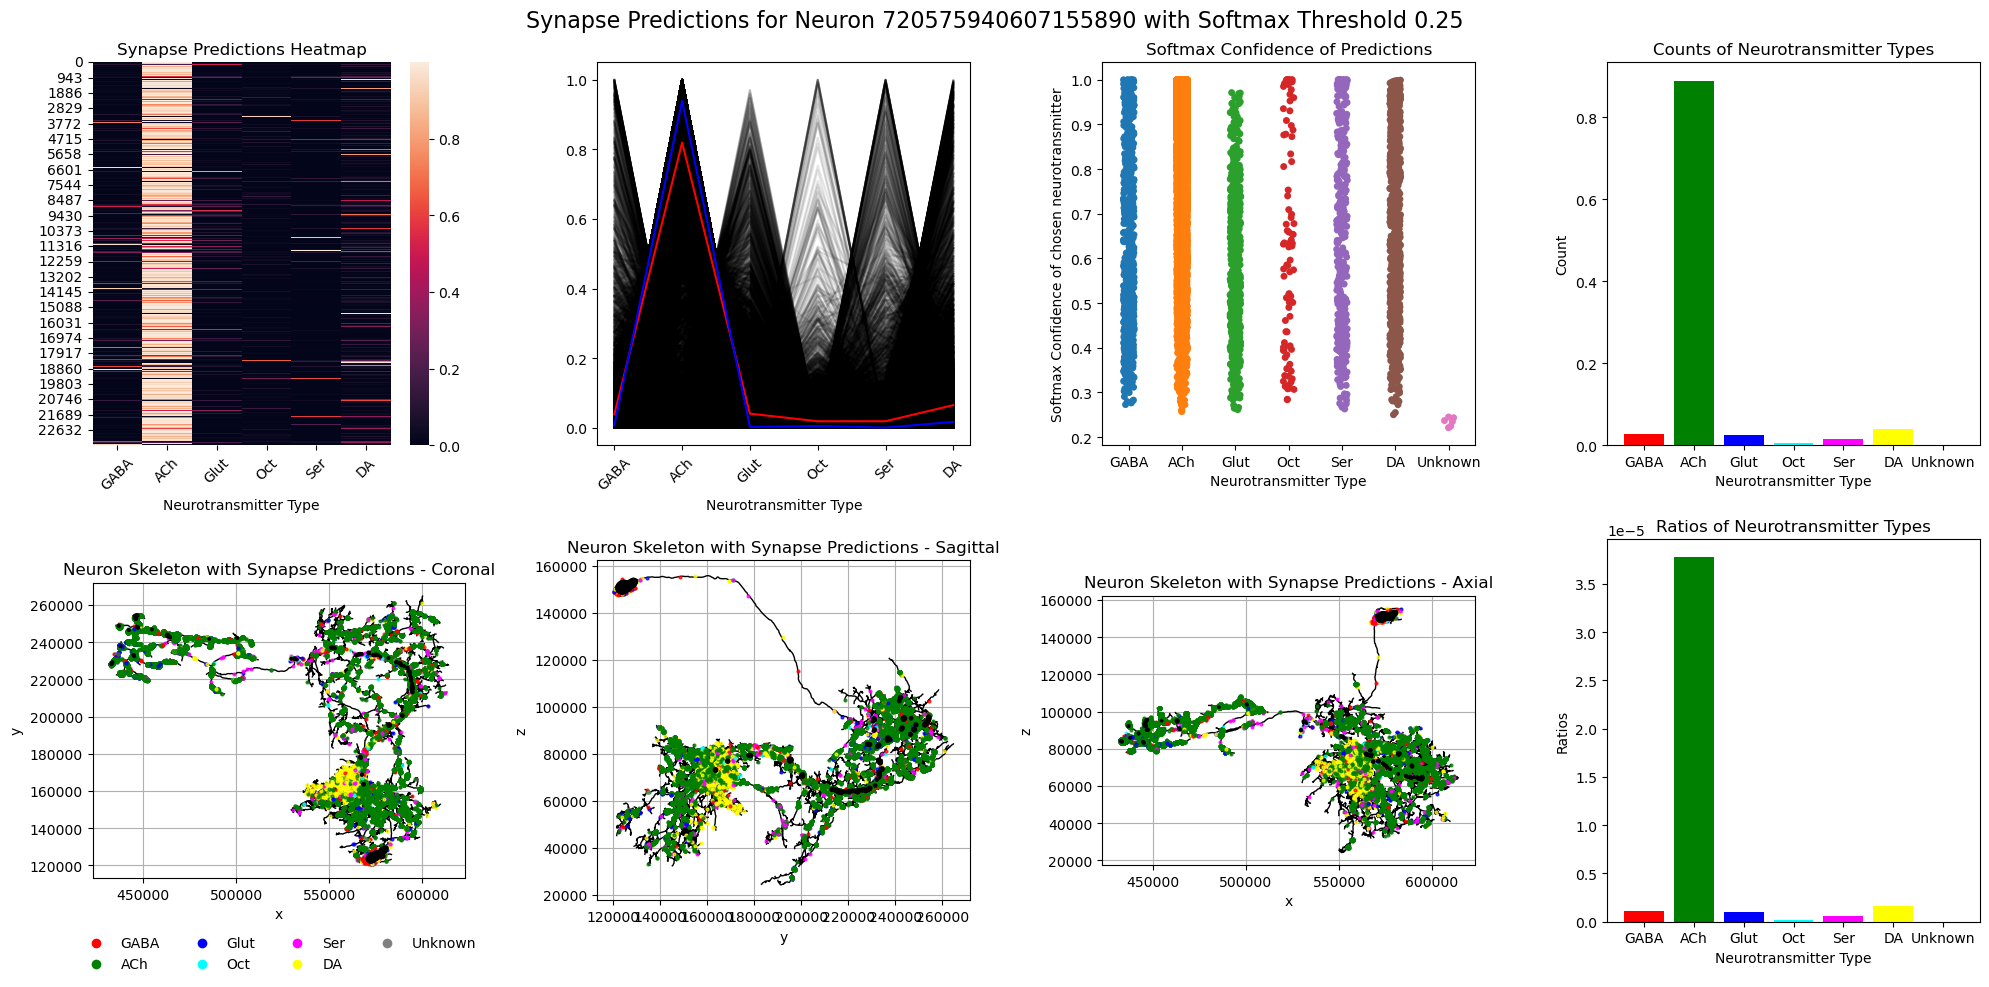

In [8]:
ratios = identify_nt_contributions_for_neuron(root_id, client, softmax_threshold=0.25, ratio_threshold=0.16, display_fig=True)

## Trial for clustering
### DBSCAN

In [10]:
# Get the synapse predictions
pre_df = get_codex_synapse_predictions(root_id, client)

# Identify neurotransmitter contributions
nt_counts, synapse_predictions = identify_nt_contributions(pre_df, 0.25)

print(f"Neurotransmitter contributions for root ID {root_id}:")
for nt, count in nt_counts.items():
    print(f"{nt}: {count:.2f}") 
print("\nSynapse Predictions:")
print(synapse_predictions)

Neurotransmitter contributions for root ID 720575940607155890:
GABA: 0.03
ACh: 0.89
Glut: 0.02
Oct: 0.00
Ser: 0.01
DA: 0.04
Unknown: 0.00

Synapse Predictions:
[[1.7340377e-02 6.4045139e-02 3.8678184e-02 3.1796805e-04 3.3392623e-02
  8.4622574e-01]
 [5.2927262e-03 3.1027919e-01 6.2390682e-03 3.2515714e-03 6.6261375e-01
  1.2323594e-02]
 [4.9337901e-02 7.9686725e-01 2.6185155e-02 7.6065450e-03 7.2335051e-03
  1.1276963e-01]
 ...
 [1.1657224e-01 7.9218882e-01 1.8135149e-02 5.6109199e-04 1.5120691e-02
  5.7421938e-02]
 [7.4751480e-03 7.8358233e-01 1.6334309e-04 8.8357323e-05 8.6301600e-04
  2.0782779e-01]
 [1.5979700e-02 9.1035491e-01 7.3515377e-03 3.1924721e-02 1.5367227e-04
  3.4235414e-02]]


In [11]:
# Extract XYZ coordinates
xyz_coords = pre_df['pre_pt_position'].values
print(xyz_coords)

[array([563932, 171384,  74560]) array([563400, 193200,  50560])
 array([564620, 230624,  74480]) ... array([503060, 220832,  94360])
 array([604200, 252996,  73480]) array([559472, 244360,  95240])]


In [12]:
synapse_ids = []
for i in range(pre_df.shape[0]):
    #Create a code for the synapse type
    synapse_type = np.argmax(synapse_predictions[i])
    softmax_val = np.max(synapse_predictions[i])
    if softmax_val < 0.25:
        synapse_type = 6
    synapse_ids.append(synapse_type)
pre_df['synapse_type'] = synapse_ids
display(pre_df.head())

,id,created,superceded_id,valid,connection_score,cleft_score,gaba,ach,glut,oct,ser,da,valid_nt,pre_pt_supervoxel_id,pre_pt_root_id,post_pt_supervoxel_id,post_pt_root_id,pre_pt_position,post_pt_position,synapse_type
0,508985,2021-03-09 20:14:58.183080+00:00,NaN,t,86.188599,142,0.017340,0.064045,0.038678,0.000318,0.033393,0.846226,t,80293211209681776,720575940607155890,80293211209687414,720575940607155890,"[563932, 171384, 74560]","[564024, 171448, 74560]",5
1,15429442,2021-03-09 20:14:58.183080+00:00,NaN,t,164.778198,112,0.005293,0.310279,0.006239,0.003252,0.662614,0.012324,t,80293554739826794,720575940607155890,80293554739826764,720575940397140598,"[563400, 193200, 50560]","[563528, 193208, 50520]",4
2,524492,2021-03-09 20:14:58.183080+00:00,NaN,t,26.879395,144,0.049338,0.796867,0.026185,0.007607,0.007234,0.112770,t,80294173282369181,720575940607155890,80294173282351514,720575940608123791,"[564620, 230624, 74480]","[564656, 230608, 74400]",1
3,1059342,2021-03-09 20:14:58.183080+00:00,NaN,t,17.228376,30,0.028138,0.666006,0.005373,0.002674,0.007495,0.290314,t,80927904296794384,720575940607155890,80927904296791557,720575940659019649,"[600952, 254196, 74040]","[601008, 254136, 74040]",1
4,27594708,2021-03-09 20:14:58.183080+00:00,NaN,t,94.334541,7,0.204758,0.160491,0.156203,0.006174,0.074122,0.398252,t,80081830099025888,720575940607155890,80081830099029582,720575940387491554,"[551012, 157524, 67720]","[550936, 157340, 67680]",5


In [13]:
cluster_df = pre_df[['pre_pt_position', 'synapse_type']].copy()
cluster_df.to_csv('synapse_clusters.csv', index=False)
print("Synapse clusters saved to 'synapse_clusters.csv'.")

Synapse clusters saved to 'synapse_clusters.csv'.


### K nearest neighbours per neurotransmitter
This is done in order to find the correct values for min_num and epsilon

Processing NT type 0 with 636 synapses.
Processing NT type 1 with 20971 synapses.
Processing NT type 2 with 579 synapses.
Processing NT type 3 with 94 synapses.
Processing NT type 4 with 350 synapses.
Processing NT type 5 with 925 synapses.
Processing NT type 6 with 6 synapses.
Skipping NT type 6 for k=10 due to insufficient synapses.
Skipping NT type 6 for k=15 due to insufficient synapses.
Skipping NT type 6 for k=20 due to insufficient synapses.


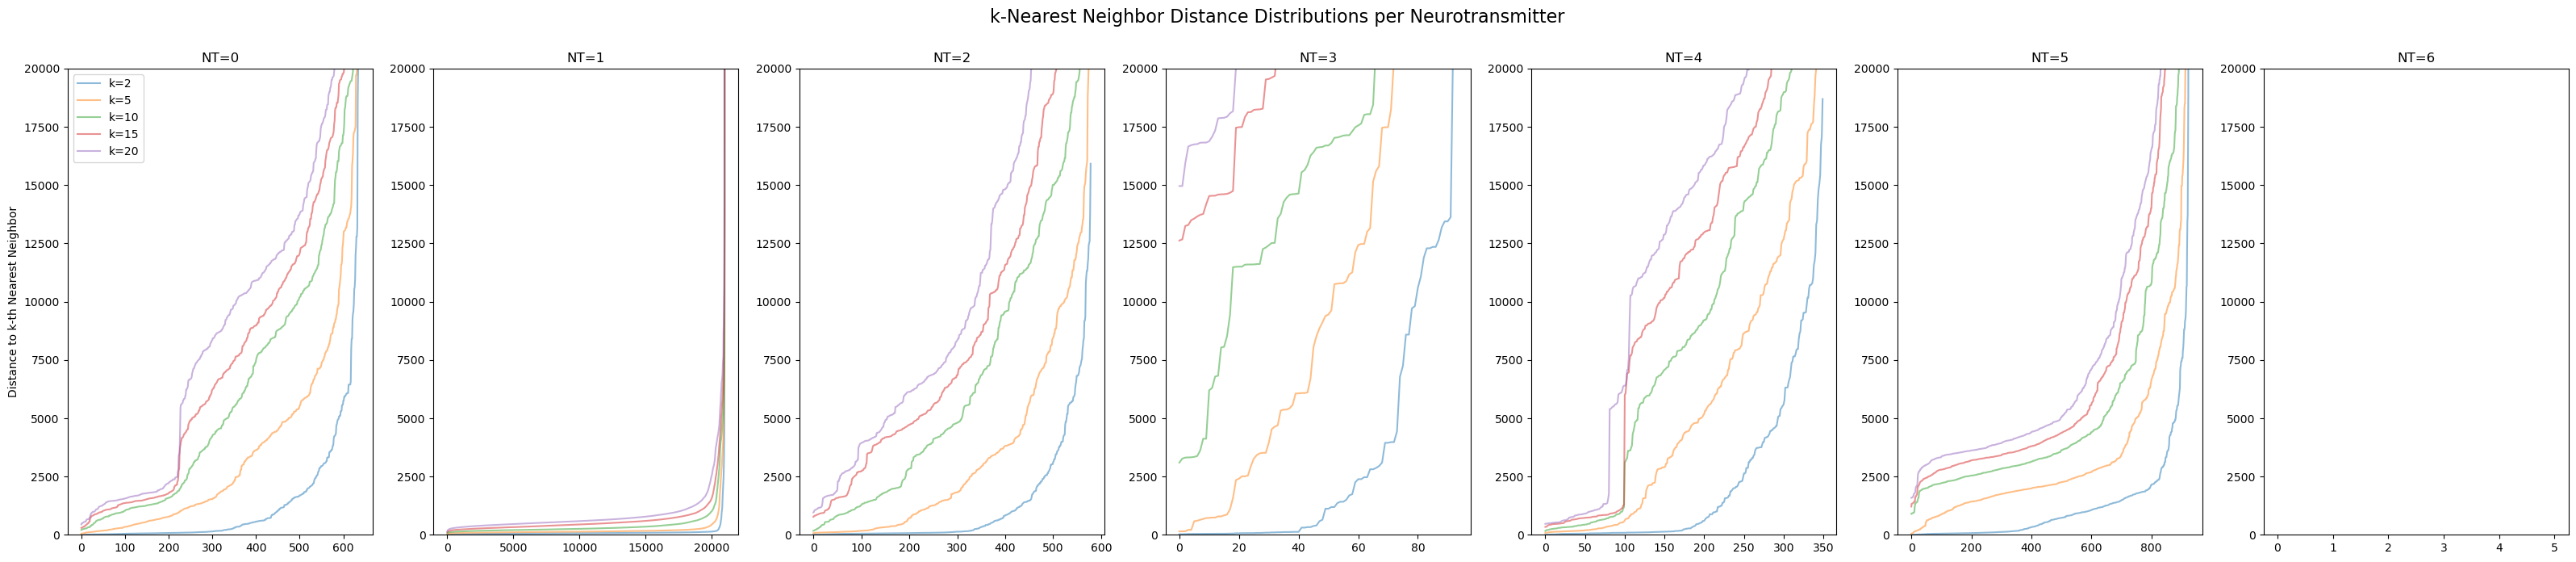

In [14]:
from sklearn.neighbors import NearestNeighbors

k_values = [2, 5, 10, 15, 20]

# List of unique NT types
nt_types = sorted(cluster_df['synapse_type'].unique())

fig, ax = plt.subplots(1, len(nt_types), figsize=(40, 7.5))
fig.suptitle("k-Nearest Neighbor Distance Distributions per Neurotransmitter", fontsize=16)
# Loop through the NT type
for nt_idx, nt in enumerate(nt_types):
    # Filter the DataFrame for the current NT type
    nt_df = cluster_df[cluster_df['synapse_type'] == nt]
    
    # Extract the coordinates for the current NT type
    coords = np.array([pos for pos in nt_df['pre_pt_position'].values])
    print(f"Processing NT type {nt} with {coords.shape[0]} synapses.")

    for k_idx, k in enumerate(k_values):
        if coords.shape[0] < k:
            print(f"Skipping NT type {nt} for k={k} due to insufficient synapses.")
            continue
        # Fit Nearest Neighbors model
        nbrs = NearestNeighbors(n_neighbors=k).fit(coords)
        distances, indices = nbrs.kneighbors(coords)
        kth_distances = np.sort(distances[:, -1])
        # Plot the distribution of distances
        ax[nt_idx].plot(kth_distances, label=f'k={k}', alpha=0.5)
        ax[nt_idx].set_title(f'NT={nt}')
        ax[nt_idx].set_ylim(0, 20000)
        if k_idx == 0:
            ax[0].legend()
            ax[0].set_ylabel('Distance to k-th Nearest Neighbor')

Ok so my eps and min cluster setting will be
* `eps` = 7500 (7.5um / 7500nm)
* `min_samples` = 10

In [15]:
from sklearn.cluster import DBSCAN
def apply_dbscan(coords, eps=7500, min_samples=10):
    """
    Apply DBSCAN clustering to the given coordinates.
    
    Parameters:
    coords (np.ndarray): Array of coordinates.
    eps (float): The maximum distance between two samples for one to be considered as in the neighborhood of the other.
    min_samples (int): The number of samples in a neighborhood for a point to be considered as a core point.
    
    Returns:
    np.ndarray: Labels for each point indicating the cluster it belongs to.
    """
    db = DBSCAN(eps=eps, min_samples=min_samples).fit(coords)
    return db.labels_

def nt_clusters(nt_df, eps=7500, min_samples=10):
    """
    Apply DBSCAN clustering to the synapses of a specific neurotransmitter type.
    
    Parameters:
    nt_df (pd.DataFrame): DataFrame containing synapse data for a specific neurotransmitter type.
    eps (float): The maximum distance between two samples for one to be considered as in the neighborhood of the other.
    min_samples (int): The number of samples in a neighborhood for a point to be considered as a core point.
    
    Returns:
    np.ndarray: Labels for each point indicating the cluster it belongs to.
    """
    coords = np.array([pos for pos in nt_df['pre_pt_position'].values])
    return apply_dbscan(coords, eps, min_samples)

In [16]:
nt_df = cluster_df[cluster_df['synapse_type'] == 0]  # Example for GABA
eps = 10000  # 7.5um in nm
min_samples = 25  # Minimum number of samples in a neighborhood
labels = nt_clusters(nt_df, eps, min_samples)
values, counts = np.unique(labels, return_counts=True)
print("Cluster labels and their counts:")
for value, count in zip(values, counts):
    print(f"Label {value}: {count} synapses")

Cluster labels and their counts:
Label -1: 250 synapses
Label 0: 54 synapses
Label 1: 229 synapses
Label 2: 30 synapses
Label 3: 44 synapses
Label 4: 29 synapses


In [17]:
values, counts = np.unique(labels, return_counts=True)
print("Cluster labels and their counts:")
for value, count in zip(values, counts):
    print(f"Label {value}: {count} synapses")

Cluster labels and their counts:
Label -1: 250 synapses
Label 0: 54 synapses
Label 1: 229 synapses
Label 2: 30 synapses
Label 3: 44 synapses
Label 4: 29 synapses


In [18]:
cluster_df

,pre_pt_position,synapse_type
0,"[563932, 171384, 74560]",5
1,"[563400, 193200, 50560]",4
2,"[564620, 230624, 74480]",1
3,"[600952, 254196, 74040]",1
4,"[551012, 157524, 67720]",5
...,...,...
23556,"[479576, 240608, 98840]",1
23557,"[599072, 246448, 70600]",1
23558,"[503060, 220832, 94360]",1
23559,"[604200, 252996, 73480]",1


## Try mean shift clustering

In [ ]:
from sklearn.cluster import estimate_bandwidth, mean_shift

def estimate_bandwidth(coords, quantile=0.2, n_samples=500):
    """
    Estimate the bandwidth for mean shift clustering.
    
    Parameters:
    coords (np.ndarray): Array of coordinates.
    quantile (float): The quantile to use for bandwidth estimation.
    n_samples (int): Number of samples to use for estimation.
    
    Returns:
    float: Estimated bandwidth.
    """
    return estimate_bandwidth(coords, quantile=quantile, n_samples=n_samples)

In [19]:
# Get the synapse predictions
pre_df = get_codex_synapse_predictions(root_id, client)
pre_df.head()

,id,created,superceded_id,valid,connection_score,cleft_score,gaba,ach,glut,oct,ser,da,valid_nt,pre_pt_supervoxel_id,pre_pt_root_id,post_pt_supervoxel_id,post_pt_root_id,pre_pt_position,post_pt_position
0,508985,2021-03-09 20:14:58.183080+00:00,NaN,t,86.188599,142,0.017340,0.064045,0.038678,0.000318,0.033393,0.846226,t,80293211209681776,720575940607155890,80293211209687414,720575940607155890,"[563932, 171384, 74560]","[564024, 171448, 74560]"
1,15429442,2021-03-09 20:14:58.183080+00:00,NaN,t,164.778198,112,0.005293,0.310279,0.006239,0.003252,0.662614,0.012324,t,80293554739826794,720575940607155890,80293554739826764,720575940397140598,"[563400, 193200, 50560]","[563528, 193208, 50520]"
2,524492,2021-03-09 20:14:58.183080+00:00,NaN,t,26.879395,144,0.049338,0.796867,0.026185,0.007607,0.007234,0.112770,t,80294173282369181,720575940607155890,80294173282351514,720575940608123791,"[564620, 230624, 74480]","[564656, 230608, 74400]"
3,1059342,2021-03-09 20:14:58.183080+00:00,NaN,t,17.228376,30,0.028138,0.666006,0.005373,0.002674,0.007495,0.290314,t,80927904296794384,720575940607155890,80927904296791557,720575940659019649,"[600952, 254196, 74040]","[601008, 254136, 74040]"
4,27594708,2021-03-09 20:14:58.183080+00:00,NaN,t,94.334541,7,0.204758,0.160491,0.156203,0.006174,0.074122,0.398252,t,80081830099025888,720575940607155890,80081830099029582,720575940387491554,"[551012, 157524, 67720]","[550936, 157340, 67680]"


In [32]:
from sklearn.cluster import estimate_bandwidth, mean_shift
all_coords = np.array([pos for pos in pre_df['pre_pt_position'].values])
total_synapses = all_coords.shape[0]

# Calculate Parameters for mean shift clustering
bandwidth = estimate_bandwidth(all_coords, quantile=1/7) #Set to 1/the total number of NT types (1/7)
min_synapses = int(total_synapses * 0.01)  # Set to 1% of the total number of synapses
print(f"Estimated bandwidth: {bandwidth}")
print(f"Minimum synapses per cluster: {min_synapses}")

# Add the synapse type to the DataFrame
synapse_ids = []
for i in range(pre_df.shape[0]):
    #Create a code for the synapse type
    synapse_type = np.argmax(synapse_predictions[i])
    softmax_val = np.max(synapse_predictions[i])
    if softmax_val < 0.25:
        synapse_type = 6
    synapse_ids.append(synapse_type)
pre_df['synapse_type'] = synapse_ids
pre_df.head()

# Loop through each neurotransmitter type and apply mean shift clustering
for nt_type in range(7):
    print(f"Processing NT type {nt_type}...")
    nt_df = pre_df[pre_df['synapse_type'] == nt_type]
    coords = np.array([pos for pos in nt_df['pre_pt_position'].values])
    if coords.shape[0] < 2:
        print(f"Skipping NT type {nt_type} due to insufficient synapses.")
        continue
    cluster_centers,labels = mean_shift(coords, bandwidth=bandwidth)
    # print(f"NT type {nt_type} has {len(np.unique(labels))} clusters.")

    # Filter clusters with fewer than min_synapses
    unique_labels, counts = np.unique(labels, return_counts=True)
    print(f"unique labels for NT type {nt_type}:", unique_labels)
    print(f"Counts for NT type {nt_type}:", counts)
    valid_labels = unique_labels[counts >= min_synapses]
    # Now print the cluster centers and sizes
    print(f"Valid labels for NT type {nt_type} are: {valid_labels}")
    
    n_clusters = len(valid_labels)
    if n_clusters > 0:
        print(f"NT type {nt_type} has a valid number of clusters:", n_clusters)


# for i, nt_type in enumerate(nt_types):
#     nt_df = pre_df[pre_df['synapse_type'] == i]
#     coords = np.array([pos for pos in nt_df['pre_pt_position'].values])
#     if coords.shape[0] < 2:
#         print(f"Skipping NT type {nt_type} due to insufficient synapses.")
#         continue
#     labels, _ = mean_shift(coords, bandwidth=bandwidth)
#     print(f"NT type {nt_type} has {len(np.unique(labels))} clusters.")

Estimated bandwidth: 28241.40610567211
Minimum synapses per cluster: 235
Processing NT type 0...
unique labels for NT type 0: [0 1 2 3]
Counts for NT type 0: [216 193 161  66]
Valid labels for NT type 0 are: []
Processing NT type 1...
unique labels for NT type 1: [0 1 2 3 4 5 6 7 8]
Counts for NT type 1: [5172 5997 3348 2133 2084 2021  206    6    4]
Valid labels for NT type 1 are: [0 1 2 3 4 5]
NT type 1 has a valid number of clusters: 6
Processing NT type 2...
unique labels for NT type 2: [0 1 2 3 4 5 6]
Counts for NT type 2: [156 165 100  55  51  38  14]
Valid labels for NT type 2 are: []
Processing NT type 3...
unique labels for NT type 3: [0 1 2 3 4 5]
Counts for NT type 3: [44 17 12  8  7  6]
Valid labels for NT type 3 are: []
Processing NT type 4...
unique labels for NT type 4: [0 1 2 3 4 5 6]
Counts for NT type 4: [91 72 64 40 38 40  5]
Valid labels for NT type 4 are: []
Processing NT type 5...
unique labels for NT type 5: [0 1 2 3 4 5 6]
Counts for NT type 5: [407 155 225  84 

In [28]:
# Loop NT types with estimate
for nt_type in range(7):
    nt_df = pre_df[pre_df['synapse_type'] == nt_type]
    coords = np.array([pos for pos in nt_df['pre_pt_position'].values])
    if coords.shape[0] < 2:
        print(f"Skipping NT type {nt_type} due to insufficient synapses.")
        continue
    cluster_centers,labels = mean_shift(coords, bandwidth=bandwidth)
    print(f"NT type {nt_type} has {len(np.unique(labels))} clusters.")
    # Now print the cluster centers and sizes
    for center, label in zip(cluster_centers, np.unique(labels)):
        print(f"Cluster {label}: Center = {center}, Size = {np.sum(labels == label)}")

NT type 0 has 4 clusters.
Cluster 0: Center = [568574.89017341 161552.87861272  72064.27745665], Size = 216
Cluster 1: Center = [453314.65714286 239109.28571429  89963.14285714], Size = 193
Cluster 2: Center = [590190.88659794 234404.65979381  70476.28865979], Size = 161
Cluster 3: Center = [572645.21212121 123820.66666667 150098.18181818], Size = 66
NT type 1 has 9 clusters.
Cluster 0: Center = [452404.50900901 237534.86936937  89038.42985843], Size = 5172
Cluster 1: Center = [572736.12661023 156187.04747884  71820.37541406], Size = 5997
Cluster 2: Center = [482165.23217726 237577.19171484  96728.31406551], Size = 3348
Cluster 3: Center = [591261.5300622  230454.52246026  68598.38286109], Size = 2133
Cluster 4: Center = [581330.60294118 193957.45424837  69128.21895425], Size = 2084
Cluster 5: Center = [566338.52115813 239542.54075724  84052.36525612], Size = 2021
Cluster 6: Center = [572764.46376812 124359.30434783 149973.33333333], Size = 206
Cluster 7: Center = [572662. 165508. 1532

In [30]:
pre_df.shape[0]*0.01

235.61

## Put it all together
Ok so my conclusions are
For every neuron 
* Filter by ratios
* Filter by clusters
    * Use mean-shift cluster

### All Helper function

In [ ]:
# Libraries
import numpy as np
import pandas as pd
from decouple import config, Config, RepositoryEnv
from caveclient import CAVEclient
from fafbseg import flywire
from sklearn.cluster import estimate_bandwidth, mean_shift
import seaborn as sns
import matplotlib.pyplot as plt
import navis

#### Base Functions

In [33]:
# Function 1: Get the dataframes
def get_codex_synapse_predictions(root_id, client):
    """
    Function to gather synapse predictions for a given root ID.
    """

    # Pull initial data from the CAVE client
    pre_df = client.materialize.query_table(
        table='synapses_nt_v1',
        filter_in_dict={'pre_pt_root_id': [root_id]},
    )

    return pre_df

# Function 2: Get the neuron skeleton
def get_neuron_skeleton(root_id):
    """
    Function to gather the neuron skeleton for a given root ID.
    """
    neuron_skeleton = flywire.get_skeletons(root_id)

    return neuron_skeleton

# Function 3: Identify NT contributions per neuron
def identify_nt_contributions(pre_df, softmax_threshold=0.25):
    """
    Function to identify neurotransmitter contributions per neuron.
    Inputs:
    pre_df: DataFrame containing synapse predictions with columns for each neurotransmitter type.
    softmax_threshold: Float, the threshold below which a neurotransmitter is considered 'Unknown'.

    Returns:
    nt_counts: a dictionary with counts of each neurotransmitter type.
    synapse_predictions: a numpy array with synapse predictions for each neurotransmitter type. (NB excludes 'Unknown' type)
    """

    #Synapse predictions
    synapse_predictions = np.zeros((len(pre_df), 6), dtype=np.float32)
    for i in range(pre_df.shape[0]):
        row = [pre_df.iloc[i]['gaba'], pre_df.iloc[i]['ach'], pre_df.iloc[i]['glut'], pre_df.iloc[i]['oct'], pre_df.iloc[i]['ser'], pre_df.iloc[i]['da']]
        synapse_predictions[i] = row
        
    # Define neurotransmitter types
    nt_types = ['GABA', 'ACh', 'Glut', 'Oct', 'Ser', 'DA', 'Unknown']
    
    # Initialize counts and filter along softmax values
    nt_counts = {nt: 0 for nt in nt_types}
    softmax_prediction_vals = {nt: [] for nt in nt_types}

    for i in range(pre_df.shape[0]):
        # Determine the synapse type based on the maximum prediction value  
        synapse_type = np.argmax(pre_df.iloc[i][['gaba', 'ach', 'glut', 'oct', 'ser', 'da']].values)
        softmax_val = np.max(pre_df.iloc[i][['gaba', 'ach', 'glut', 'oct', 'ser', 'da']].values)
        if softmax_val < softmax_threshold:
            synapse_type = 6  # Assign 'Unknown' if below threshold
        
        # Add the softmax value to the corresponding neurotransmitter type
        softmax_prediction_vals[nt_types[synapse_type]].append(softmax_val)
        
        # Increment the count for the neurotransmitter type
        nt_counts[nt_types[synapse_type]] += 1
    
    # Convert to ratios
    total_synapses = pre_df.shape[0]
    for nt in nt_counts.keys():
        if total_synapses > 0:
            nt_counts[nt] = nt_counts[nt] / total_synapses
        else:
            nt_counts[nt] = 0
    
    return nt_counts, synapse_predictions

##### Ratio Functions

In [51]:
# Function 4: Predict which NTs the neuron uses via ratios
def predict_neurotransmitter_usage_ratios(nt_used, nt_counts, ratio_threshold):
    """
    Function to predict which neurotransmitters a neuron uses based on ratios.
    Returns a list of neurotransmitter types that exceed the ratio threshold.

    Inputs:
    nt_used: List of boolean values indicating whether each neurotransmitter is used.
    nt_counts: Dictionary with ratio of each neurotransmitter type.
    ratio_threshold: Float, the threshold above which a neurotransmitter is considered used.
    """
    c = 0
    for nt, ratio in nt_counts.items():
        if ratio >= ratio_threshold:
            nt_used[c] = True
        c += 1

    return nt_used

#### Cluster Functions

In [52]:
# Function 5: Mean Shift Clustering
def predict_neurotransmitter_usage_clustering(pre_df, nt_used, bandwidth_quantile=1/7, min_synapses_ratio=0.01):
    """
    Function to predict neurotransmitter usage based on clustering.
    Returns a list of neurotransmitter types that are used based on clustering.

    Inputs:
    pre_df: DataFrame containing synapse predictions with columns for each neurotransmitter type.
    
    Returns:
    nt_used: List of boolean values indicating whether each neurotransmitter is used.
    """
    temp_df = pre_df.copy()
    all_coords = np.array([pos for pos in pre_df['pre_pt_position'].values])
    total_synapses = all_coords.shape[0]

    # Calculate Parameters for mean shift clustering
    bandwidth = estimate_bandwidth(all_coords, quantile=bandwidth_quantile) #Set to 1/the total number of NT types (1/7)
    min_synapses = int(total_synapses * min_synapses_ratio)  # Set to 1% of the total number of synapses
    print(f"Estimated bandwidth: {bandwidth}")
    print(f"Minimum synapses per cluster: {min_synapses}")

    # Add the synapse type to the DataFrame
    synapse_ids = []
    for i in range(pre_df.shape[0]):
        #Create a code for the synapse type
        synapse_type = np.argmax(synapse_predictions[i])
        softmax_val = np.max(synapse_predictions[i])
        if softmax_val < 0.25:
            synapse_type = 6
        synapse_ids.append(synapse_type)
    temp_df['synapse_type'] = synapse_ids

    # Loop through each neurotransmitter type and apply mean shift clustering
    for nt_type in range(7):
        nt_df = temp_df[temp_df['synapse_type'] == nt_type]
        coords = np.array([pos for pos in nt_df['pre_pt_position'].values])
        if coords.shape[0] < 2:
            print(f"Skipping NT type {nt_type} due to insufficient synapses.")
            continue
        cluster_centers, labels = mean_shift(coords, bandwidth=bandwidth)
        
        # Filter clusters with fewer than min_synapses
        unique_labels, counts = np.unique(labels, return_counts=True)
        valid_labels = unique_labels[counts >= min_synapses]        
        n_clusters = len(valid_labels)

        if n_clusters > 0:
            print(f"NT type {nt_type} has a valid number of clusters:", n_clusters)
            nt_used[nt_type] = True
        else:
            print(f"NT type {nt_type} has no valid clusters.")
            nt_used[nt_type] = False

    return nt_used

#### Final Function

In [ ]:
def identify_nt_contributions_for_neuron(root_id, 
                                         client, 
                                         softmax_threshold=0.25, 
                                         ratio_threshold=0.16, 
                                         bandwidth_quantile_value=1/7, 
                                         min_synapses_ratio_value=0.01,
                                         display_fig=False)-> dict:
    """
    Function to identify neurotransmitter contributions per neuron.
    Inputs:
    root_id: The root ID of the neuron to analyze.
    client: The CAVE client to use for querying data.
    softmax_threshold: Float, the threshold below which a neurotransmitter is considered 'Unknown'.
    ratio_threshold: Float, the threshold above which a neurotransmitter is considered used.
    bandwidth_quantile_value: Float, the quantile to use for bandwidth estimation in clustering.
    min_synapses_ratio_value: Float, the ratio of minimum synapses required for a cluster to be considered valid.
    display_fig: Boolean, whether to display the figures or not.
    
    Returns a list of neurotransmitter types that exceed the ratio threshold.
    """
    # Get the synapse predictions
    pre_df = get_codex_synapse_predictions(root_id, client)
    
    # Identify neurotransmitter contributions
    nt_counts, synapse_predictions = identify_nt_contributions(pre_df, softmax_threshold)
    
    # Predict neurotransmitter usage based on ratios
    nt_used = np.zeros(7, dtype=bool)
    nt_used = predict_neurotransmitter_usage_ratios(nt_used, nt_counts, ratio_threshold)

    # Predict the neurotransmitter usage via clustering
    nt_used = predict_neurotransmitter_usage_clustering(pre_df,
                                                         nt_used,
                                                         synapse_predictions, 
                                                         bandwidth_quantile=bandwidth_quantile_value, 
                                                         min_synapses_ratio=min_synapses_ratio_value)
    
    # Create a output dictionary to store the results
    nt_results = {
        'root_id': root_id,
    }
    # Add the nt_used boolean array to the results with neurotransmitter names as key.
    nt_names = nt_counts.keys()
    for i, nt in enumerate(nt_names):
        nt_results[nt] = nt_used[i]
    
    # # Print the results
    # print(f"Neurotransmitter contributions for root ID {root_id}:")
    # for nt, count in nt_counts.items():
    #     print(f"{nt}: {count:.2f}")
    
    # print("\nPredicted neurotransmitters are:")
    # nt_names = nt_counts.keys()
    # for i, nt in enumerate(nt_names):
    #     if nt_used[i]:
    #         print(f"{nt} identified as used")

    if display_fig:
        neuron_skeleton = get_neuron_skeleton(root_id)
        # Plot the neuron skeleton with neurotransmitter contributions
        fig, ax = plt.subplots(2,4, figsize=(20, 10))

        # Plot the synapse predictions as a heatmap
        sns.heatmap(synapse_predictions, ax=ax[0,0])
        ax[0,0].set_title('Synapse Predictions Heatmap')
        ax[0,0].set_xlabel('Neurotransmitter Type')
        ax[0,0].set_xticks(np.arange(6) + 0.5)
        ax[0,0].set_xticklabels(['GABA', 'ACh', 'Glut', 'Oct', 'Ser', 'DA'], rotation=45)

        # Plot each row of the synapse predictions as a line plot
        for i in range(synapse_predictions.shape[0]):
            ax[0,1].plot(synapse_predictions[i], color='k', label=f'Synapse {i+1}', alpha=0.1)
        mean_predictions = np.mean(synapse_predictions, axis=0)
        median_predictions = np.median(synapse_predictions, axis=0)
        ax[0,1].plot(mean_predictions, label='Mean', color='r')
        ax[0,1].plot(median_predictions, label='Median', color='blue')
        ax[0,1].set_xlabel('Neurotransmitter Type')
        ax[0,1].set_xticks([0, 1, 2, 3, 4, 5])
        ax[0,1].set_xticklabels(['GABA', 'ACh', 'Glut', 'Oct', 'Ser', 'DA'], rotation=45)

        # Plot the neuron skeleton with the synapse predictions - all 3 combinations
        navis.plot2d(neuron_skeleton, ax=ax[1,0], color='k', view='xy')
        navis.plot2d(neuron_skeleton, ax=ax[1,1], color='k', view='yz')
        navis.plot2d(neuron_skeleton, ax=ax[1,2], color='k', view='xz')

        # Define neurotransmitter types and colors
        present_types = set()
        softmax_prediction_vals = {
            'GABA': [],
            'ACh': [],
            'Glut': [],
            'Oct': [],
            'Ser': [],
            'DA': [],
            'Unknown': []
        }
        nt_types = ['GABA', 'ACh', 'Glut', 'Oct', 'Ser', 'DA', 'Unknown']
        colours = ['red', 'green', 'blue', 'cyan', 'magenta', 'yellow', 'gray']

        for i in range(synapse_predictions.shape[0]):
            # Determine the synapse type based on the maximum prediction value  
            synapse_type = np.argmax(synapse_predictions[i])
            softmax_val = np.max(synapse_predictions[i])
            if softmax_val < softmax_threshold:
                synapse_type = 6  # Assign 'Unknown' if below threshold
            colour = colours[synapse_type]
            present_types.add(synapse_type)

            # Add the softmax value to the corresponding neurotransmitter type
            softmax_prediction_vals[nt_types[synapse_type]].append(softmax_val)
        
            # Find the position of the pre-synapse
            pos = pre_df.iloc[i]['pre_pt_position']
            pos_xy = (pos[0], pos[1])
            pos_yz = (pos[1], pos[2])
            pos_xz = (pos[0], pos[2])
        
            # Plot the synapse prediction on the neuron skeleton
            ax[1,0].plot(pos_xy[0], pos_xy[1], 'o', color=colour, markersize=2, alpha=0.75)
            ax[1,1].plot(pos_yz[0], pos_yz[1], 'o', color=colour, markersize=2, alpha=0.75)
            ax[1,2].plot(pos_xz[0], pos_xz[1], 'o', color=colour, markersize=2, alpha=0.75)
    
        # Create legend entries only for neurotransmitter types that are present
        legend_elements = []
        for nt_idx in sorted(present_types):
            legend_elements.append(plt.Line2D([0], [0], marker='o', color='w', 
                                            markerfacecolor=colours[nt_idx], markersize=8,
                                            label=nt_types[nt_idx]))
    
        # Place the legend horizontally below the x-axis
        ax[1,0].legend(
            handles=legend_elements,
            loc='upper center',
            bbox_to_anchor=(0.5, -0.18),
            borderaxespad=0.,
            ncol=round(len(legend_elements)/2),
            frameon=False
        )
        ax[1,0].set_title('Neuron Skeleton with Synapse Predictions - Coronal')
        ax[1,1].set_title('Neuron Skeleton with Synapse Predictions - Sagittal')
        ax[1,2].set_title('Neuron Skeleton with Synapse Predictions - Axial')

        # Plot the counts of each neurotransmitter type
        ax[0,3].bar(nt_counts.keys(), nt_counts.values(), color=colours)
        ax[0,3].set_xlabel('Neurotransmitter Type')
        ax[0,3].set_ylabel('Count')
        ax[0,3].set_title('Counts of Neurotransmitter Types')

        # Plot the counts of each neurotransmitter type
        pcts = [nt_counts[nt] / synapse_predictions.shape[0] for nt in nt_counts.keys()]
        ax[1,3].bar(nt_counts.keys(), pcts, color=colours)
        ax[1,3].set_xlabel('Neurotransmitter Type')
        ax[1,3].set_ylabel('Ratios')
        ax[1,3].set_title('Ratios of Neurotransmitter Types')
        
        # Softmax confidence of the predictions
        sns.stripplot(data=softmax_prediction_vals, ax=ax[0,2])
        ax[0,2].set_title('Softmax Confidence of Predictions')
        ax[0,2].set_xlabel('Neurotransmitter Type')
        ax[0,2].set_ylabel('Softmax Confidence of chosen neurotransmitter')

        plt.suptitle(f'Synapse Predictions for Neuron {root_id} with Softmax Threshold {softmax_threshold}', fontsize=16)
        plt.tight_layout()
        plt.show()
    
    return nt_results

In [62]:
nt_results = identify_nt_contributions_for_neuron(root_id, 
                                              client, 
                                              softmax_threshold=0.25, 
                                              ratio_threshold=0.16, 
                                              bandwidth_quantile_value=1/7, 
                                              min_synapses_ratio_value=0.01,
                                              display_fig=False)
print(f"result: {nt_results}")

TypeError: predict_neurotransmitter_usage_clustering() got multiple values for argument 'bandwidth_quantile'

In [56]:
nt_results["cell_type"] = "test_cell_type"
_df = pd.DataFrame([nt_results])

In [57]:
_df

,root_id,GABA,ACh,Glut,Oct,Ser,DA,Unknown,cell_type
0,720575940607155890,False,True,False,False,False,True,False,test_cell_type
